# Visão computacional
**TÓPICOS A SEREM ABORDADOS:**
- Processamento de imagens
  - Imagem como matriz
  - Abrir/ler imagens
  - Redimensionar
  - Espelhar (flip)
  - Rotacionar
  - Binarizar (threshold)
  - Convolução (filtro linear)
- Redes neurais convolucionais (CNN)
  - Treinar uma CNN para classificação de imagens

## Processamento de imagens
Caso não tenha o opencv instalado, pode usar  comando:
```python
!pip install opencv-python
```

A documentação completa para opencv pode ser encontrada
[aqui](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

In [1]:
# Importação de módulos
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Imagem como uma matriz


Para entender melhor o padrão de cores RGB pode usar [seletor de cores](https://g.co/kgs/yJJG7Lv) para selecionar uma tupla de cor.

In [2]:
# Uma imagem com 2x2 pixels
img0 = np.array([
    [[ 61, 231,  3], # pixel 1, canto superior esquerdo
    [ 68,  24,  78]], # pixel 2, canto superior direito

    [[162, 107, 33], # pixel 3, canto inferior esquerdo
    [223,  62, 139]]  # pixel 4, canto inferior direito
    ])
img0

array([[[ 61, 231,   3],
        [ 68,  24,  78]],

       [[162, 107,  33],
        [223,  62, 139]]])

In [3]:
# Para ver o shape do array
img0.shape


(2, 2, 3)

In [4]:

# Para ver a dimensão do array
img0.ndim

3

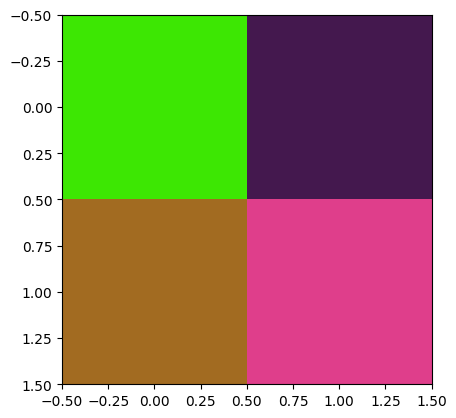

In [5]:
# Visualizar a imagem
plt.imshow(img0, cmap='gray')
plt.show()

In [6]:
# Uma imagem monocromática 2x2 pixels
img1 = np.array([
    [123, # pixel 1, canto superior esquerdo
    93], # pixel 2, canto superior direito

    [33, # pixel 3, canto inferior esquerdo
    255]  # pixel 4, canto inferior direito
    ])
img1

array([[123,  93],
       [ 33, 255]])

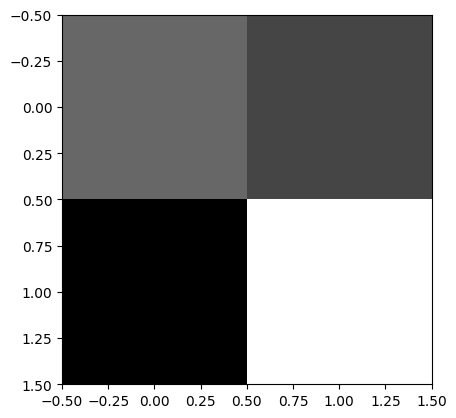

In [7]:
# Exibir a imagem
'''Para garantir que a imagem de tons de cinza seja exibida corretamente,
sempre inclua o argumento cmap='gray' ao usar plt.imshow()
com imagens em tons de cinza
'''
plt.imshow(img1, cmap='gray')
plt.show()

In [8]:
# Para ver o shape do array
img1.shape


(2, 2)

In [9]:

# Para ver a dimensão do array
img1.ndim

2

In [10]:
# Para ver o tipo de dados
img1.dtype

dtype('int64')

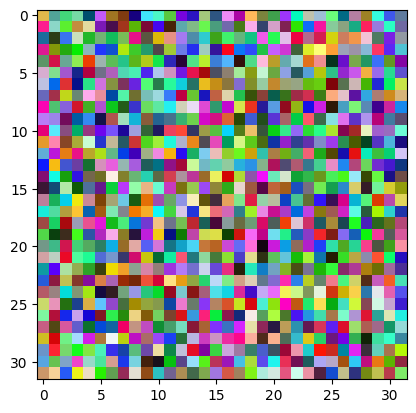

In [11]:
# Podemos criar uma imagem maior 32x32 pixels
#  Array aleatorio com shape 32x32
img3 = np.random.randint(0,255, (32,32, 3))
plt.imshow(img3, cmap='gray')
plt.show()

### Abrir/ler imagens
```python
cv2.imread('caminho.ext', flag)
```
A flag é opcional. Uma flag comum é cv2.IMREAD_GRAYSCALE, que abre a imagem em escala de cinza


In [12]:
!gdown 14a3oW5WDRFsCkM2sTzTYAQ84yHK7571G

Downloading...
From: https://drive.google.com/uc?id=14a3oW5WDRFsCkM2sTzTYAQ84yHK7571G
To: /home/hellsdeur/Code/lid/misc/mlcc/aula7-visao_computacional/lena.png
100%|████████████████████████████████████████| 474k/474k [00:00<00:00, 1.67MB/s]


In [13]:
# from google.colab import files
# uploaded = files.upload()


In [14]:
# Ler imagens
img4 = cv2.imread('lena.png')
img4_rgb = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB) # Converter de BGR para RGB
img4_gray = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY) # Converter de BGR para escala de cinza

In [15]:
img4

array([[[125, 137, 226],
        [125, 137, 226],
        [133, 137, 223],
        ...,
        [122, 148, 230],
        [110, 130, 221],
        [ 90,  99, 200]],

       [[125, 137, 226],
        [125, 137, 226],
        [133, 137, 223],
        ...,
        [122, 148, 230],
        [110, 130, 221],
        [ 90,  99, 200]],

       [[125, 137, 226],
        [125, 137, 226],
        [133, 137, 223],
        ...,
        [122, 148, 230],
        [110, 130, 221],
        [ 90,  99, 200]],

       ...,

       [[ 60,  18,  84],
        [ 60,  18,  84],
        [ 58,  27,  92],
        ...,
        [ 84,  73, 173],
        [ 76,  68, 172],
        [ 79,  62, 177]],

       [[ 57,  22,  82],
        [ 57,  22,  82],
        [ 62,  32,  96],
        ...,
        [ 79,  70, 179],
        [ 81,  71, 181],
        [ 81,  74, 185]],

       [[ 57,  22,  82],
        [ 57,  22,  82],
        [ 62,  32,  96],
        ...,
        [ 79,  70, 179],
        [ 81,  71, 181],
        [ 81,  74, 185]]

In [16]:
# Para ver o tipo de dados
img4.dtype

dtype('uint8')

Outra forma de visualizar a imagem
```python
cv2.imshow('legenda da imagem', img4)
cv2.waitKey(0)
cv2.destroyAllWindows()
```

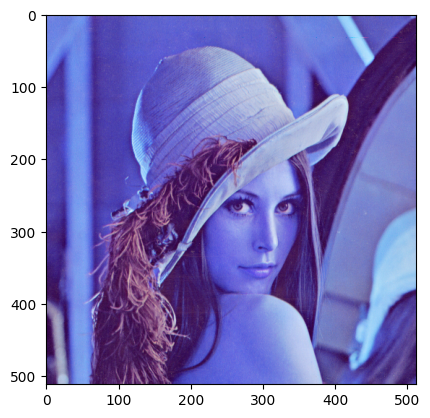

In [17]:
plt.imshow(img4, cmap='gray')
# plt.axis('off')
# plt.colorbar()
plt.show()

In [18]:
img4.shape

(512, 512, 3)

In [19]:
img4

array([[[125, 137, 226],
        [125, 137, 226],
        [133, 137, 223],
        ...,
        [122, 148, 230],
        [110, 130, 221],
        [ 90,  99, 200]],

       [[125, 137, 226],
        [125, 137, 226],
        [133, 137, 223],
        ...,
        [122, 148, 230],
        [110, 130, 221],
        [ 90,  99, 200]],

       [[125, 137, 226],
        [125, 137, 226],
        [133, 137, 223],
        ...,
        [122, 148, 230],
        [110, 130, 221],
        [ 90,  99, 200]],

       ...,

       [[ 60,  18,  84],
        [ 60,  18,  84],
        [ 58,  27,  92],
        ...,
        [ 84,  73, 173],
        [ 76,  68, 172],
        [ 79,  62, 177]],

       [[ 57,  22,  82],
        [ 57,  22,  82],
        [ 62,  32,  96],
        ...,
        [ 79,  70, 179],
        [ 81,  71, 181],
        [ 81,  74, 185]],

       [[ 57,  22,  82],
        [ 57,  22,  82],
        [ 62,  32,  96],
        ...,
        [ 79,  70, 179],
        [ 81,  71, 181],
        [ 81,  74, 185]]

### Redimensionar (resize, scale)

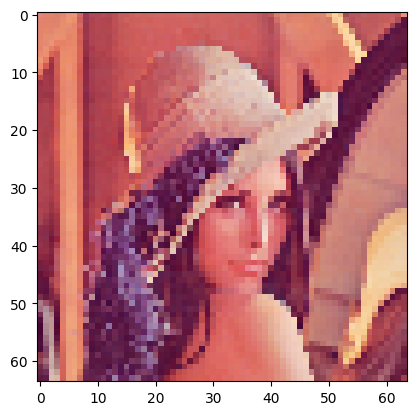

In [20]:
img4_redim = cv2.resize(img4_rgb, (64,64))

plt.imshow(img4_redim, cmap='gray')
plt.show()

### Espelhamento (flipping)

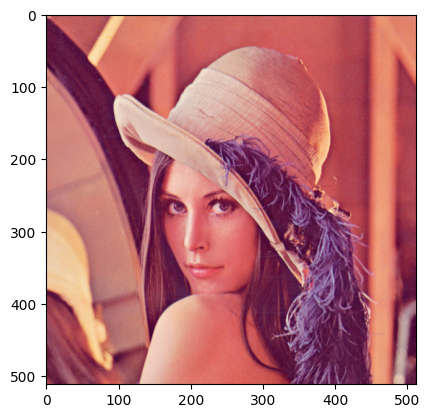

In [21]:
# Image flip
img4_espelh = cv2.flip(img4_rgb, 1) # tente passar 1,0,-1 como parametros

plt.imshow(img4_espelh)
# plt.axis('off')
plt.show()

### Rotacionar a imagem
```python
cv2.rotate(imagem,flag)
```
As flags disponíveis são:

* Rodar 90 graus no sentido anti-horário
  
`cv2.ROTATE_90_COUNTERCLOCKWISE`

* Rodar 90 graus no sentido horário
  
`cv2.ROTATE_90_CLOCKWISE`
* Rodar 180 graus no sentido horário
  
`cv2.cv2.ROTATE_180`


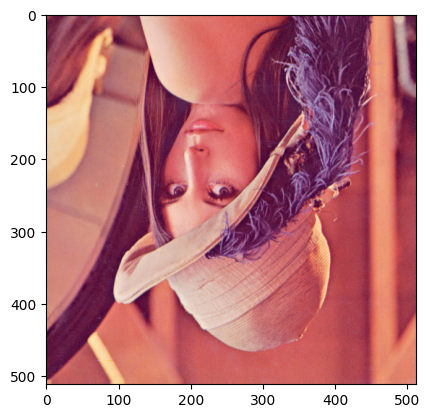

In [22]:
## Rotate 90 degree clockwise
img4_rot = cv2.rotate(img4_rgb,cv2.ROTATE_180)
plt.imshow( img4_rot, cmap='gray')
plt.show()

### Limiarizar (threshold)
```python
cv2.threshold(imagem, min_value, max_value, cv2.THRESH_OTSU)
```

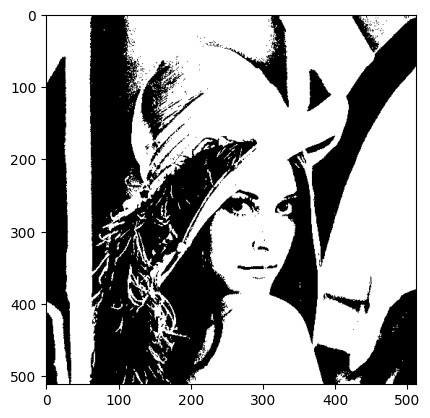

Limiar: 117.0


In [23]:
# Escolher automaticamente o threshold no openCV
'''cv2.THRESH_OTSU: Especifica o uso do método de Otsu.
O método de Otsu encontra automaticamente o valor ótimo de limiarização
para separar os pixels de fundo e de primeiro plano,
baseado na minimização da variância intra-classe (para imagens bimodais)'''
lim, img4_lim = cv2.threshold(img4_gray, 0, 255, cv2.THRESH_OTSU)
plt.imshow(img4_lim, cmap='gray')
# plt.colorbar()
plt.show()

print('Limiar:',lim)

In [24]:
# Comparar valores dos pixels
np.unique(img4_lim)
# np.unique(img4_gray)

array([  0, 255], dtype=uint8)

### Convolução (filtro linear)


In [25]:
# Filtros
edge_detection_kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
box_blur_kernel = np.array([[1, 1, 1],[1, 1, 1],[1, 1, 1]], dtype = np.float32)*(1/9)
gaussian_blurr_kernel = np.array([[1,4,6,4,1],[4,16,24,16,4],[6,24,36,24,6],[4,16,24,16,4],[1,4,6,4,1]], dtype=np.float32)*(1/256)

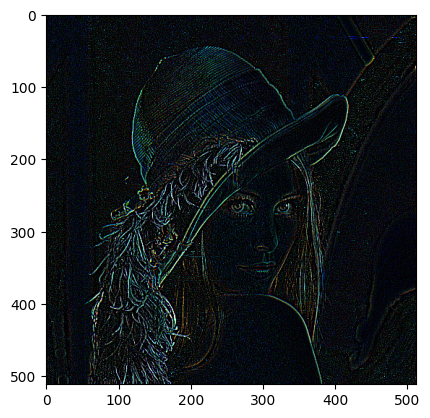

In [26]:
# Alterar o kernel
img4_filter = cv2.filter2D(src=img4_rgb, ddepth=0, kernel=edge_detection_kernel)

plt.imshow(img4_filter, cmap='gray')
plt.show()

## Redes Neurais Convolucionais

In [27]:
# Importacao de modulos
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
from sklearn.metrics import confusion_matrix

2025-06-03 15:13:56.063078: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-03 15:13:56.073432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748974436.085624   90101 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748974436.089770   90101 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748974436.099961   90101 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

**O conjunto de dados CiFAR10**

CIFAR-10 é um dos mais conhecidos conjuntos de dados de visão computacional, frequentemente utilizado para treinar e avaliar modelos de redes neurais, especialmente em tarefas de classificação de imagens. Ele foi criado por pesquisadores da Universidade de Toronto, liderados por Alex Krizhevsky e Geoffrey Hinton (Nobel da física 2024).

As classes são:

0 - Avião (airplane)

1 - Automóvel (automobile)

2 - Pássaro (bird)

3 - Gato (cat)

4 - Cervo (deer)

5 - Cachorro (dog)

6 - Sapo (frog)

7 - Cavalo (horse)

8 - Navio (ship)

9 - Caminhão (truck)

In [28]:
# Carregar o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 179s 1us/step


In [29]:
# Verificar shape, dimension & data type
x_train.shape

(50000, 32, 32, 3)

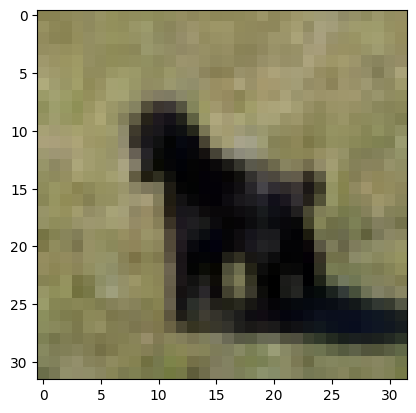

Na imagem tem um Cachorro.


In [30]:
# VISUALIZAR ALGUMAS IMAGENS EXISTENTES
# Listar os nomes das classes
classes = ['Avião', 'Automóvel', 'Pássaro', 'Gato', 'Cervo', 'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']

# Selecionar um número aleatorio
nr_imagem = np.random.randint(50000)

# Mostrar a imagem correspondente no conjunto de treino
plt.imshow(x_train[nr_imagem])
plt.show()

print(f'Na imagem tem um {classes[y_train[nr_imagem][0]]}.')

In [31]:
# NORMALIZAR E CODIFICAR OS DADOS
# Normalizar os dados
x_train = x_train.astype('float32') / 255.0

# One-hot encode os rótulos
y_train = to_categorical(y_train, 10)

In [32]:
# CRIAR A REDE NEURAL
# Definir o modelo sequencial
'''
Por padrão, o padding é 'valid' (reduz a dimensão da imagem) nas camadas de convolucao 2D e stride é 1
Nas camadas de MaxPooling o strid é igual ao kernel (no caso, 2)
Ao final, imagem com 32x32x3 de input é reduzida  para 4x4x64
'''
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compilar o modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Configurar o early stopping
early_stopping = EarlyStopping()

# Treinar o modelo
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[early_stopping])


I0000 00:00:1748974620.248243   90101 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1225 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1748974622.284798   91519 service.cc:152] XLA service 0x765340005390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748974622.284878   91519 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-06-03 15:17:02.307333: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748974622.476773   91519 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-06-03 15:17:03.828414: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_342', 4 bytes spill stores, 4 bytes spill loads



 44/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1198 - loss: 2.2815

I0000 00:00:1748974625.709313   91519 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3135 - loss: 1.8447 - val_accuracy: 0.5194 - val_loss: 1.3426
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5351 - loss: 1.2918 - val_accuracy: 0.5702 - val_loss: 1.2177
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6061 - loss: 1.1142 - val_accuracy: 0.6242 - val_loss: 1.0573
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6416 - loss: 1.0108 - val_accuracy: 0.6500 - val_loss: 0.9940
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6706 - loss: 0.9302 - val_accuracy: 0.6649 - val_loss: 0.9507
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7071 - loss: 0.8380 - val_accuracy: 0.6772 - val_loss: 0.9249
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7253 - loss: 0.7778 - val_accuracy: 0.6889 - val_loss: 0.8885
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7426 - loss: 0.7326 - val_accuracy: 0.6854 - val_

In [33]:
# PREVISOES
# Fazer previsoes com o modelo
y_pred = model.predict(x_test)

# Converter de one hot encoder para inteiros numéricos
y_pred = np.argmax(y_pred, axis=1).reshape(-1,1)

2025-06-03 15:17:29.144146: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 4 bytes spill stores, 4 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


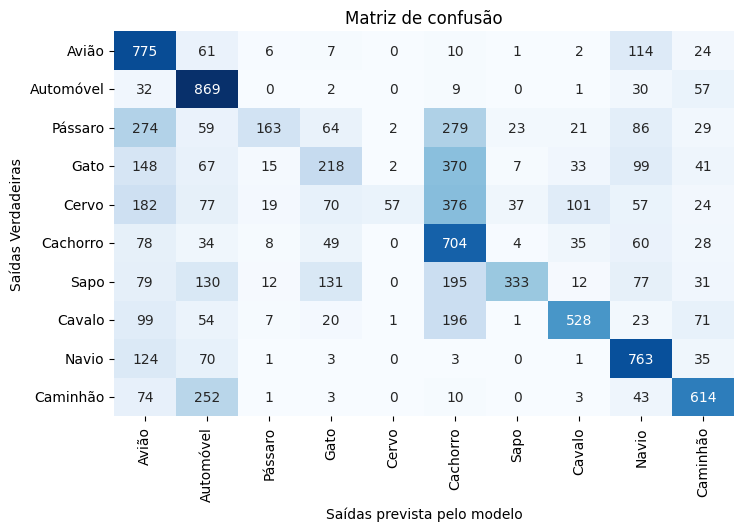

In [34]:
# ANALISAR A MATRIZ DE CONFUSAO
# Gerar a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotar usando Seaborn
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.xlabel('Saídas prevista pelo modelo')
plt.ylabel('Saídas Verdadeiras')
plt.title('Matriz de confusão')
plt.show()

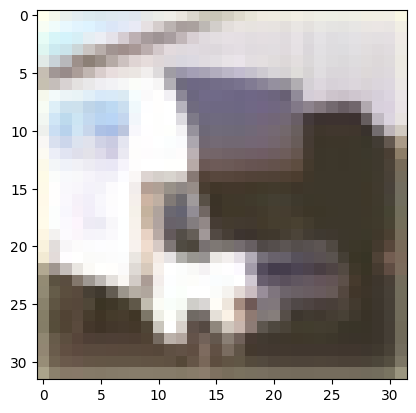

Resposta esperada: Caminhão.
Resposta do modelo: Cavalo.


In [35]:
# VISUALIZAR ALGUMAS IMAGENS PREVISOES DO MODELO
# Selecionar um número aleatorio até 10000
nr_imagem = np.random.randint(10000)

# Mostrar a imagem correspondente no conjunto de treino
plt.imshow(x_test[nr_imagem])
plt.show()

print(f'Resposta esperada: {classes[y_test[nr_imagem][0]]}.')
print(f'Resposta do modelo: {classes[y_pred[nr_imagem][0]]}.')

## Tarefas:
1. Plotar o gráfico do treinamento para a acurácia e erro durante o treinamento
2. Tentar treinar o modelo  sem as camadas de convolução e comparar:
   - O tempo de treinamento
   - A acurácia
   - O número de parâmetros